In [2]:
import os
import numpy as np
import pandas as pd
import pandas_market_calendars as mcal
import datetime as dt
from data_processor import DataReader, DataPrep
from scipy import stats
import pandas_ta as ta
from matplotlib import pyplot as plt
from scipy.stats import norm
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
pd.set_option('display.float_format', '{:.10f}'.format)

### EDA

In [3]:
# daily_data_path = r'data/daily_data'
# intraday_data_path = r'data/intraday_data'
# intraday_df = DataReader.read_intraday_data(intraday_data_path)
# daily_df = DataReader.read_daily_data(daily_data_path)
# intraday_df.to_pickle('intraday_df.pkl')
# daily_df.to_pickle('daily_df.pkl')

In [4]:
daily_df = pd.read_pickle('daily_df.pkl')
intraday_df =  pd.read_pickle('intraday_df.pkl')
data_prep = DataPrep(intraday_df, daily_df)
target_df = data_prep.get_target(clip_MAD=True, normalize= True)
X_df = data_prep.get_features()
input_data = X_df.join(target_df[['y', 'y_actual_clipped']], how = 'right')

## Features

#### Volume

In [ ]:
input_data.VolumeChangeNormalize.hist(bins = 30)

#### Intraday RSI

In [ ]:
input_data.IntradayRSI.hist(bins = 30)

In [ ]:
clipped_returns = [col for col in input_data.columns if 'clipped' in col and 'Return' in col]
features = clipped_returns + ['VolumeChangeNormalize', 'IntradayRSI']

In [ ]:
input_data[features + ['y']].corr()

#### Returns

In [ ]:

not_clipped_returns = [col for col in input_data.columns if 'clipped' not in col and 'Return' in col]

In [ ]:
for col in clipped_returns:
    input_data[col].hist(bins = 30)
    plt.title(col) 
    plt.show()

#### CumReturnResid

## Target Var Distribution

In [6]:
input_data

Time  CumReturnResid  CumReturnRaw  \
Date       Id                                                     
2010-01-05 BBG000MQ1SN9  15:30:00    0.0010412260 -0.0096762910   
           BBG000BBB3K1  15:30:00    0.0114658960 -0.0005634935   
           BBG000BNMHS4  15:30:00   -0.0008671929  0.0074492240   
           BBG000NDV1D4  15:30:00   -0.0195770540  0.0025141472   
           BBG000C23PB0  15:30:00    0.0045224130 -0.0057656015   
...                           ...             ...           ...   
2014-12-30 BBG000GZQ728  15:30:00    0.0029190893  0.0016119565   
           BBG000BPH459  15:30:00    0.0013052966 -0.0094838515   
           BBG000CKGBP2  15:30:00   -0.0124181200 -0.0205038670   
           BBG000MM2P62  15:30:00   -0.0048366560 -0.0091225900   
           BBG000B9XRY4  15:30:00   -0.0067255697 -0.0128610650   

                                  CumVolume      MDV_63_sqrt   MIC  \
Date       Id                                                        
2010-01-05 BBG000MQ1SN9   643496.0000000000  6620.6304835718  XNYS   
           BBG000BBB3K1   758735.0000000000  8711.2720081513  XNYS   
           BBG000BNMHS4   731415.0000000000  6643.3372637553  XNYS   
           BBG000NDV1D4  3672872.0000000000  6970.1796246582  XNYS   
           BBG000C23PB0  3588394.0000000000  6663.7385903110  XNYS   
...                                     ...              ...   ...   
2014-12-30 BBG000GZQ728  6315633.0000000000 35742.3138590663  XNYS   
           BBG000BPH459 11323714.0000000000 37568.7050615269  XNGS   
           BBG000CKGBP2 14988807.0000000000 39638.7638555997  XNGS   
           BBG000MM2P62 11850871.0000000000 48827.0519282088  XNGS   
           BBG000B9XRY4 23827172.0000000000 71410.1813469200  XNGS   

                            AD_preday Stock_Split Dividend  \
Date       Id                                                
2010-01-05 BBG000MQ1SN9 -1.1876508955       False    False   
           BBG000BBB3K1 -1.1866433883       False    False   
           BBG000BNMHS4 -1.1819793994       False    False   
           BBG000NDV1D4 -1.1314636412       False    False   
           BBG000C23PB0 -1.1715990087       False    False   
...                               ...         ...      ...   
2014-12-30 BBG000GZQ728 -0.0491177639       False    False   
           BBG000BPH459 -0.1113596035       False    False   
           BBG000CKGBP2  0.1793013591       False    False   
           BBG000MM2P62  0.0653353084       False    False   
           BBG000B9XRY4 -0.2028198451       False    False   

                              Volume_preday  ...  Rolling_Return_16d_clipped  \
Date       Id                                ...                               
2010-01-05 BBG000MQ1SN9   955120.0000000000  ...                0.9192404912   
           BBG000BBB3K1   812905.0000000000  ...               -0.9746397660   
           BBG000BNMHS4  1108030.0000000000  ...                0.9295669974   
           BBG000NDV1D4  5311553.0000000000  ...                0.5489693832   
           BBG000C23PB0  3500468.0000000000  ...                0.3424439751   
...                                     ...  ...                         ...   
2014-12-30 BBG000GZQ728  9556343.0000000000  ...                0.8745375003   
           BBG000BPH459 14417173.0000000000  ...               -5.8977578735   
           BBG000CKGBP2 20570292.0000000000  ...               -1.3767347305   
           BBG000MM2P62 14101566.0000000000  ...                6.4262496105   
           BBG000B9XRY4 27528272.0000000000  ...               -2.1354649052   

                         Rolling_Return_17d_clipped  \
Date       Id                                         
2010-01-05 BBG000MQ1SN9                0.9192404912   
           BBG000BBB3K1               -0.9746397660   
           BBG000BNMHS4                0.9295669974   
           BBG000NDV1D4                0.5489693832   
           BBG000C23PB0                0.3424439751   
...          

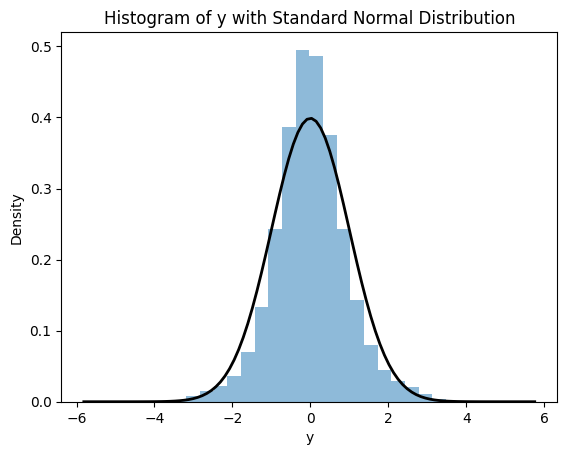

In [5]:
# Plot the histogram of 'y'
plt.hist(input_data.y, bins=30, alpha=0.5, density=True)

# Superimpose the standard normal distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = np.exp(-x**2 / 2) / np.sqrt(2 * np.pi)
plt.plot(x, p, 'k', linewidth=2)

# plt.legend()
plt.title('Histogram of y with Standard Normal Distribution')
plt.xlabel('y')
plt.ylabel('Density')

# Show the plot
plt.show()

In [ ]:
stats.probplot(input_data.y, dist="norm", plot=plt)
plt.title('Normal P-P Plot of Data')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')

# Show the plot
plt.show()

### Stationarity Test

In [ ]:
target_by_id = input_data.reset_index().pivot(index = 'Id', columns = 'Date', values='y')

In [ ]:
nonstationary = {}
for id in target_by_id.index:
    try:
        p_val = adfuller(target_by_id.loc[id].dropna())[1]
        if p_val > 0.05:
            nonstationary[id] = p_val
    except:
        pass

In [ ]:
nonstationary

## Target Var Distribution By Exchange

In [ ]:
from itertools import combinations

In [ ]:
p_vals = {}
for ex1, ex2 in combinations(input_data.MIC.unique(), 2):
    p_vals[(ex1, ex2)] = stats.ks_2samp(input_data.query('MIC == @ex1').y,input_data.query('MIC == @ex2').y).pvalue
    
exchanges = input_data.MIC.unique()
exchanges

exchanges_mapping = {
    'XNYS': 'New York Stock Exchange (NYSE)',
    'XNGS': 'NASDAQ Global Select Market',
    'XNMS': 'NASDAQ Global Market',
    'XASE': 'NYSE American (formerly American Stock Exchange, AMEX)'
}

In [ ]:
target_by_id = target_by_id.dropna()

def diff_distribution_frac(input_data, exchange = None):
    query_df = input_data.query('MIC == @exchange') if exchange else input_data
    stock_pairs = combinations(query_df.index.get_level_values('Id').unique(), 2)
    p_vals = {}
    for id1, id2 in stock_pairs:
        try:
            p_vals[(id1, id2)] = stats.ks_2samp(target_by_id.loc[id1],target_by_id.loc[id2]).pvalue
        except:
            pass
       
    return len([v for _, v in p_vals.items() if v < 0.05]) / len(p_vals) if len(p_vals)  else np.nan

In [ ]:
{e:diff_distribution_frac(input_data,e) for e in exchanges}

In [ ]:
diff_distribution_frac(input_data)

In [ ]:
 stats.ks_2sap(input_data.query('MIC == @ex1').y,input_data.query('MIC == @ex2').y).

In [ ]:
for ex in input_data.MIC.unique():
    input_data.query('MIC == @ex').y.hist(bins=30)